# Calculate nu given alpha, d for a range of alpha and d
### see the colab notebook : nu_over_d_against_alpha_chart_20260424.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

### calculate from scratch by running the code below 
### or just call the function 
### get_alpha_vals_conjectured_limit_vals_nu_over_d_vals() 
### for the pre-computed hard-coded values

In [18]:
# combine these sets
arr1 = np.arange(0.1, 1.0, 0.01)
arr2 = np.arange(1.0, 2.0, 0.02)
arr3 = np.arange(2.0, 3.0, 0.05)
arr4 = np.arange(3.0, 5.0, 0.1)
arr5 = np.arange(5.0, 10.2, 0.2)
combined = np.unique(np.concatenate((arr1, arr2)))
combined = np.unique(np.concatenate((combined, arr3)))
combined = np.unique(np.concatenate((combined, arr4)))
combined = np.unique(np.concatenate((combined, arr5)))
alpha_vals = combined

In [19]:
print(len(alpha_vals))

206


In [33]:
d = 1000000
nu_over_d_vals = np.zeros(len(alpha_vals))
uniform_draws = True

i = 0
for alpha in alpha_vals:
  nu_alpha_over_d = pp.calculate_nu_alpha_d(alpha, d, uniform_draws) / d
  nu_over_d_vals[i] = nu_alpha_over_d
  print(f"alpha = {alpha}, nu_alpha_over_d = {nu_alpha_over_d}")
  i+=1

alpha = 0.1, nu_alpha_over_d = 1.0019892034680272e-06
alpha = 0.11, nu_alpha_over_d = 1.0037676967008774e-06
alpha = 0.12, nu_alpha_over_d = 1.0064360206407699e-06
alpha = 0.13, nu_alpha_over_d = 1.010157621188005e-06
alpha = 0.13999999999999999, nu_alpha_over_d = 1.0150686252166628e-06
alpha = 0.14999999999999997, nu_alpha_over_d = 1.0212779305052294e-06
alpha = 0.15999999999999998, nu_alpha_over_d = 1.0288701489560058e-06
alpha = 0.16999999999999998, nu_alpha_over_d = 1.0379098369879993e-06
alpha = 0.17999999999999997, nu_alpha_over_d = 1.0484460140975168e-06
alpha = 0.18999999999999995, nu_alpha_over_d = 1.060516414760838e-06
alpha = 0.19999999999999996, nu_alpha_over_d = 1.0741512175351122e-06
alpha = 0.20999999999999996, nu_alpha_over_d = 1.0893761757529657e-06
alpha = 0.21999999999999995, nu_alpha_over_d = 1.1062151726115706e-06
alpha = 0.22999999999999995, nu_alpha_over_d = 1.1246922699560169e-06
alpha = 0.23999999999999994, nu_alpha_over_d = 1.1448333362035522e-06
alpha = 0.249

In [34]:
#nu_over_d_d100_vals = nu_over_d_vals
#nu_over_d_d1000_vals = nu_over_d_vals
#nu_over_d_d10000_vals = nu_over_d_vals
#nu_over_d_d100000_vals = nu_over_d_vals
nu_over_d_d1000000_vals = nu_over_d_vals


In [21]:
conjectured_limit_vals = np.zeros(len(alpha_vals))

i = 0
for alpha in alpha_vals:
  nu_alpha_over_d = pp.calculate_conjectured_limiting_value_nu_over_d(alpha)
  conjectured_limit_vals[i] = nu_alpha_over_d
  print(f"alpha = {alpha}, nu_alpha_over_d = {nu_alpha_over_d}")
  i += 1

alpha = 0.1, nu_alpha_over_d = 0.0
alpha = 0.11, nu_alpha_over_d = 0.0
alpha = 0.12, nu_alpha_over_d = 0.0
alpha = 0.13, nu_alpha_over_d = 0.0
alpha = 0.13999999999999999, nu_alpha_over_d = 0.0
alpha = 0.14999999999999997, nu_alpha_over_d = 0.0
alpha = 0.15999999999999998, nu_alpha_over_d = 0.0
alpha = 0.16999999999999998, nu_alpha_over_d = 0.0
alpha = 0.17999999999999997, nu_alpha_over_d = 0.0
alpha = 0.18999999999999995, nu_alpha_over_d = 0.0
alpha = 0.19999999999999996, nu_alpha_over_d = 0.0
alpha = 0.20999999999999996, nu_alpha_over_d = 0.0
alpha = 0.21999999999999995, nu_alpha_over_d = 0.0
alpha = 0.22999999999999995, nu_alpha_over_d = 0.0
alpha = 0.23999999999999994, nu_alpha_over_d = 0.0
alpha = 0.24999999999999992, nu_alpha_over_d = 0.0
alpha = 0.2599999999999999, nu_alpha_over_d = 0.0
alpha = 0.2699999999999999, nu_alpha_over_d = 0.0
alpha = 0.2799999999999999, nu_alpha_over_d = 0.0
alpha = 0.2899999999999999, nu_alpha_over_d = 0.0
alpha = 0.29999999999999993, nu_alpha_over_d 

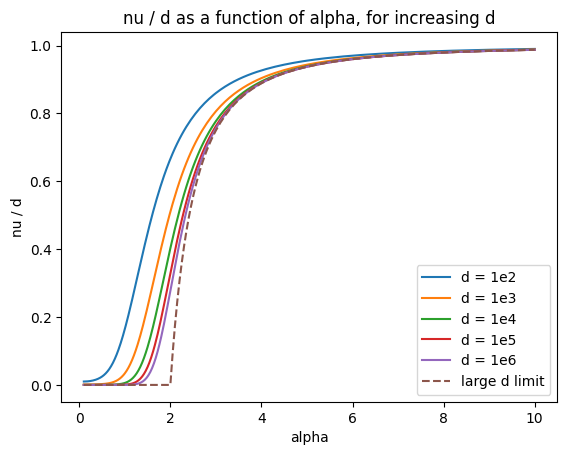

In [35]:
this_title = "nu / d as a function of alpha, for increasing d"

plt.plot(alpha_vals, nu_over_d_d100_vals, label = "d = 1e2")
plt.plot(alpha_vals, nu_over_d_d1000_vals, label = "d = 1e3")
plt.plot(alpha_vals, nu_over_d_d10000_vals, label = "d = 1e4")
plt.plot(alpha_vals, nu_over_d_d100000_vals, label = "d = 1e5")
plt.plot(alpha_vals, nu_over_d_d1000000_vals, label = "d = 1e6") #, linestyle='--')
plt.plot(alpha_vals, conjectured_limit_vals, linestyle='--', label="large d limit")
plt.xlabel("alpha")
plt.ylabel("nu / d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_as_function_of_alpha.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
results_dict = get_alpha_nu_over_d_vals()

alpha_vals = results_dict["alpha"]
conjectured_limit_vals = results_dict["conjectured_limit"]
nu_over_d_d100_vals = results_dict["100"]
nu_over_d_d1000_vals = results_dict["1000"]
nu_over_d_d10000_vals = results_dict["10000"]
nu_over_d_d100000_vals = results_dict["100000"]
nu_over_d_d1000000_vals = results_dict["1000000"]

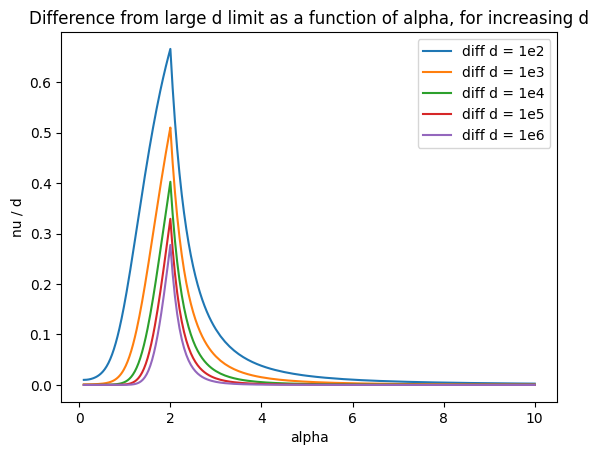

In [50]:
#print(type(nu_over_d_d100_vals))
#print(type(conjectured_limit_vals))

diff_d100 = np.array(nu_over_d_d100_vals) - np.array(conjectured_limit_vals)
#print(diff_d100.shape)
diff_d1000 = np.array(nu_over_d_d1000_vals) - np.array(conjectured_limit_vals)
diff_d10000 = np.array(nu_over_d_d10000_vals) - np.array(conjectured_limit_vals)
diff_d100000 = np.array(nu_over_d_d100000_vals) - np.array(conjectured_limit_vals)
diff_d1000000 = np.array(nu_over_d_d1000000_vals) - np.array(conjectured_limit_vals)

this_title = "Difference from large d limit as a function of alpha, for increasing d"
plt.plot(alpha_vals, diff_d100, label = "diff d = 1e2")
plt.plot(alpha_vals, diff_d1000, label = "diff d = 1e3")
plt.plot(alpha_vals, diff_d10000, label = "diff d = 1e4")
plt.plot(alpha_vals, diff_d100000, label = "diff d = 1e5")
plt.plot(alpha_vals, diff_d1000000, label = "diff d = 1e6")
plt.xlabel("alpha")
plt.ylabel("nu / d")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_difference_from_large_d_limit.pdf', dpi=300, bbox_inches='tight')
plt.show()

### graph of nu/d for alpha = 2, as d increases
### This should tend to zero
### calculate from scratch by running the code below
### or just call the function get_log_d_vals_nu_over_d_vals_alpha_2()

In [51]:
num_vals = 8
log10d_vals = np.arange(1, num_vals + 1, 1)
nu_vals = np.zeros(num_vals)
log10_d_vals = np.zeros(num_vals)
log10_nu_vals = np.zeros(num_vals)
log10_nu_over_d_vals = np.zeros(num_vals)
nu_over_d_vals = np.zeros(num_vals)
alpha = 1.9

for i in log10d_vals:
  d = 10**i
  this_nu = pp.calculate_nu_alpha_d(alpha, d)
  log10_nu = math.log10(this_nu)
  log10_d = math.log10(d)
  log10_nu_over_d = log10_nu - log10_d
  nu_over_d = this_nu / d #10**log10_nu_over_d
  nu_vals[i-1] = this_nu
  log10_d_vals[i-1] = log10_d
  log10_nu_vals[i-1] = log10_nu
  log10_nu_over_d_vals[i-1] = log10_nu_over_d
  nu_over_d_vals[i-1] = nu_over_d
  print(i, d, this_nu, log10_nu, log10_nu_over_d, nu_over_d)

1 10 5.199656337218408 0.7159746405998342 -0.2840253594001658 0.5199656337218408
2 100 40.93514289051448 1.6120963107009936 -0.3879036892990064 0.40935142890514475
3 1000 57.791723497874294 1.7618656464382656 -1.2381343535617344 0.057791723497874294
4 10000 2129.0201027869216 3.3281797621843126 -0.6718202378156874 0.21290201027869216
5 100000 29959.60160146998 4.476536033879445 -0.5234639661205547 0.2995960160146998
6 1000000 220997.18127227944 5.34438673447379 -0.6556132655262097 0.22099718127227944
7 10000000 1992985.4612775915 6.299504130557012 -0.7004958694429879 0.19929854612775916
8 100000000 19753720.81586143 7.2956489114864675 -0.7043510885135325 0.1975372081586143


In [39]:
xx_alpha = pp.clean_array(alpha_vals, num_decimal_places=6)
print("xx_alpha = ", xx_alpha)

xx_conjectured = pp.clean_array(conjectured_limit_vals, num_decimal_places=6)
print(xx_conjectured)

xx_alpha =  [0.1, 0.11, 0.12, 0.13, 0.14, 0.149999, 0.159999, 0.169999, 0.179999, 0.189999, 0.199999, 0.209999, 0.219999, 0.229999, 0.239999, 0.249999, 0.259999, 0.269999, 0.279999, 0.289999, 0.299999, 0.309999, 0.319999, 0.329999, 0.339999, 0.349999, 0.359999, 0.369999, 0.379999, 0.389999, 0.399999, 0.409999, 0.419999, 0.429999, 0.439999, 0.449999, 0.459999, 0.469999, 0.479999, 0.489999, 0.499999, 0.509999, 0.519999, 0.529999, 0.539999, 0.549999, 0.559999, 0.569999, 0.579999, 0.589999, 0.599999, 0.609999, 0.619999, 0.629999, 0.639999, 0.649999, 0.659999, 0.669999, 0.679999, 0.689999, 0.699999, 0.709999, 0.719999, 0.729999, 0.739999, 0.749999, 0.759999, 0.769999, 0.779999, 0.789999, 0.799999, 0.809999, 0.819999, 0.829999, 0.839999, 0.849999, 0.859999, 0.869999, 0.879999, 0.889999, 0.899999, 0.909999, 0.919999, 0.929999, 0.939999, 0.949999, 0.959999, 0.969999, 0.979999, 0.989999, 1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2, 1.22, 1.24, 1.26, 1.28, 1.3, 1.32, 1.34, 1.36

In [36]:
xx_d_100 = pp.clean_array(nu_over_d_d100_vals, num_decimal_places=6)
print("xx_d_100 = ", xx_d_100)

xx_d_1000 = pp.clean_array(nu_over_d_d1000_vals, num_decimal_places=6)
print("xx_d_1000 = ", xx_d_1000)

xx_d_10000 = pp.clean_array(nu_over_d_d10000_vals, num_decimal_places=6)
print("xx_d_10000 = ", xx_d_10000)

xx_d_100000 = pp.clean_array(nu_over_d_d100000_vals, num_decimal_places=6)
print("xx_d_100000 = ", xx_d_100000)

xx_d_1000000 = pp.clean_array(nu_over_d_d1000000_vals, num_decimal_places=6)
print("xx_d_1000000 = ", xx_d_1000000)

print()

xx_d_100 =  [0.010019, 0.010037, 0.010064, 0.010101, 0.01015, 0.010212, 0.010288, 0.010379, 0.010484, 0.010605, 0.010741, 0.010893, 0.011062, 0.011246, 0.011448, 0.011666, 0.011902, 0.012155, 0.012426, 0.012716, 0.013025, 0.013354, 0.013703, 0.014073, 0.014465, 0.014881, 0.01532, 0.015784, 0.016274, 0.016791, 0.017337, 0.017913, 0.018521, 0.019161, 0.019835, 0.020545, 0.021293, 0.022081, 0.02291, 0.023781, 0.024698, 0.025661, 0.026674, 0.027737, 0.028853, 0.030024, 0.031252, 0.032539, 0.033887, 0.035299, 0.036775, 0.038319, 0.039932, 0.041617, 0.043375, 0.045208, 0.047118, 0.049107, 0.051176, 0.053327, 0.055563, 0.057883, 0.06029, 0.062784, 0.065368, 0.068042, 0.070807, 0.073663, 0.076612, 0.079654, 0.08279, 0.086019, 0.089343, 0.09276, 0.096271, 0.099876, 0.103574, 0.107364, 0.111247, 0.11522, 0.119284, 0.123437, 0.127678, 0.132005, 0.136417, 0.140913, 0.145491, 0.150148, 0.154884, 0.159696, 0.164581, 0.174566, 0.184818, 0.195319, 0.206049, 0.216986, 0.228107, 0.239393, 0.250819, 0.26

In [47]:
def get_nu_over_d_vals(d : int) -> np.ndarray:
    results_dict = get_alpha_nu_over_d_vals()
    return results_dict[str(d)]

In [46]:
def get_alpha_nu_over_d_vals() -> dict:

    # hard-coded, precalculated values

    xx_alpha =  [0.1, 0.11, 0.12, 0.13, 0.14, 0.149999, 0.159999, 0.169999, 0.179999, 0.189999, 0.199999, 0.209999, 0.219999, 0.229999, 0.239999, 0.249999, 0.259999, 0.269999, 0.279999, 0.289999, 0.299999, 0.309999, 0.319999, 0.329999, 0.339999, 0.349999, 0.359999, 0.369999, 0.379999, 0.389999, 0.399999, 0.409999, 0.419999, 0.429999, 0.439999, 0.449999, 0.459999, 0.469999, 0.479999, 0.489999, 0.499999, 0.509999, 0.519999, 0.529999, 0.539999, 0.549999, 0.559999, 0.569999, 0.579999, 0.589999, 0.599999, 0.609999, 0.619999, 0.629999, 0.639999, 0.649999, 0.659999, 0.669999, 0.679999, 0.689999, 0.699999, 0.709999, 0.719999, 0.729999, 0.739999, 0.749999, 0.759999, 0.769999, 0.779999, 0.789999, 0.799999, 0.809999, 0.819999, 0.829999, 0.839999, 0.849999, 0.859999, 0.869999, 0.879999, 0.889999, 0.899999, 0.909999, 0.919999, 0.929999, 0.939999, 0.949999, 0.959999, 0.969999, 0.979999, 0.989999, 1.0, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2, 1.22, 1.24, 1.26, 1.28, 1.3, 1.32, 1.34, 1.36, 1.38, 1.4, 1.42, 1.44, 1.46, 1.48, 1.5, 1.52, 1.54, 1.56, 1.58, 1.6, 1.62, 1.64, 1.66, 1.68, 1.7, 1.72, 1.74, 1.76, 1.78, 1.8, 1.82, 1.84, 1.86, 1.88, 1.9, 1.92, 1.94, 1.96, 1.98, 2.0, 2.049999, 2.099999, 2.149999, 2.199999, 2.249999, 2.299999, 2.349999, 2.399999, 2.449999, 2.499999, 2.549999, 2.599999, 2.649999, 2.699999, 2.749999, 2.799999, 2.849999, 2.899999, 2.949999, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0, 6.2, 6.4, 6.6, 6.8, 7.0, 7.2, 7.4, 7.6, 7.8, 8.0, 8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 9.8, 10.0]
    xx_conjectured = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.09297, 0.173553, 0.243856, 0.305555, 0.359999, 0.408284, 0.451303, 0.489795, 0.524375, 0.555555, 0.583766, 0.609374, 0.63269, 0.653979, 0.673469, 0.691358, 0.707815, 0.722991, 0.737015, 0.75, 0.773242, 0.793388, 0.810964, 0.826388, 0.84, 0.852071, 0.862825, 0.872448, 0.881093, 0.888888, 0.895941, 0.902343, 0.908172, 0.913494, 0.918367, 0.922839, 0.926953, 0.930747, 0.934253, 0.9375, 0.94331, 0.948347, 0.952741, 0.956597, 0.96, 0.963017, 0.965706, 0.968112, 0.970273, 0.972222, 0.973985, 0.975585, 0.977043, 0.978373, 0.979591, 0.980709, 0.981738, 0.982686, 0.983563, 0.984375, 0.985127, 0.985827, 0.986479, 0.987086, 0.987654]

    conjectured_limit_vals = []
    for this_alpha in xx_alpha:
        conjectured_limit_vals.append(pp.calculate_conjectured_limiting_value_nu_over_d(this_alpha))
    
    xx_d_100 =  [0.010019, 0.010037, 0.010064, 0.010101, 0.01015, 0.010212, 0.010288, 0.010379, 0.010484, 0.010605, 0.010741, 0.010893, 0.011062, 0.011246, 0.011448, 0.011666, 0.011902, 0.012155, 0.012426, 0.012716, 0.013025, 0.013354, 0.013703, 0.014073, 0.014465, 0.014881, 0.01532, 0.015784, 0.016274, 0.016791, 0.017337, 0.017913, 0.018521, 0.019161, 0.019835, 0.020545, 0.021293, 0.022081, 0.02291, 0.023781, 0.024698, 0.025661, 0.026674, 0.027737, 0.028853, 0.030024, 0.031252, 0.032539, 0.033887, 0.035299, 0.036775, 0.038319, 0.039932, 0.041617, 0.043375, 0.045208, 0.047118, 0.049107, 0.051176, 0.053327, 0.055563, 0.057883, 0.06029, 0.062784, 0.065368, 0.068042, 0.070807, 0.073663, 0.076612, 0.079654, 0.08279, 0.086019, 0.089343, 0.09276, 0.096271, 0.099876, 0.103574, 0.107364, 0.111247, 0.11522, 0.119284, 0.123437, 0.127678, 0.132005, 0.136417, 0.140913, 0.145491, 0.150148, 0.154884, 0.159696, 0.164581, 0.174566, 0.184818, 0.195319, 0.206049, 0.216986, 0.228107, 0.239393, 0.250819, 0.262364, 0.274007, 0.285725, 0.297498, 0.309306, 0.321128, 0.332947, 0.344744, 0.356502, 0.368205, 0.379839, 0.391389, 0.402842, 0.414188, 0.425414, 0.436512, 0.447471, 0.458286, 0.468948, 0.479451, 0.48979, 0.499961, 0.50996, 0.519784, 0.52943, 0.538897, 0.548183, 0.557288, 0.566211, 0.574952, 0.583513, 0.591893, 0.600095, 0.608119, 0.615968, 0.623643, 0.631147, 0.638481, 0.645649, 0.652653, 0.659496, 0.666181, 0.682219, 0.697332, 0.711569, 0.724977, 0.737604, 0.749497, 0.760699, 0.771254, 0.781201, 0.790581, 0.799428, 0.807778, 0.815662, 0.82311, 0.830152, 0.836812, 0.843115, 0.849085, 0.854742, 0.860106, 0.870028, 0.878983, 0.887086, 0.894436, 0.901118, 0.907209, 0.912773, 0.917867, 0.92254, 0.926836, 0.930794, 0.934447, 0.937825, 0.940954, 0.943858, 0.946556, 0.949068, 0.951411, 0.953598, 0.955642, 0.959352, 0.962621, 0.965515, 0.96809, 0.970389, 0.972451, 0.974306, 0.975982, 0.9775, 0.978879, 0.980137, 0.981286, 0.982338, 0.983305, 0.984195, 0.985016, 0.985775, 0.986477, 0.98713, 0.987736, 0.988301, 0.988827, 0.989319, 0.98978, 0.990211]
    xx_d_1000 =  [0.001001, 0.001003, 0.001006, 0.00101, 0.001015, 0.001021, 0.001028, 0.001037, 0.001048, 0.00106, 0.001074, 0.001089, 0.001106, 0.001124, 0.001144, 0.001166, 0.00119, 0.001215, 0.001242, 0.001271, 0.001302, 0.001335, 0.00137, 0.001407, 0.001446, 0.001488, 0.001532, 0.001578, 0.001628, 0.00168, 0.001735, 0.001793, 0.001855, 0.00192, 0.001989, 0.002062, 0.002139, 0.002221, 0.002307, 0.002399, 0.002496, 0.0026, 0.002709, 0.002826, 0.002949, 0.003081, 0.00322, 0.003369, 0.003527, 0.003695, 0.003874, 0.004065, 0.004268, 0.004484, 0.004715, 0.00496, 0.005222, 0.0055, 0.005797, 0.006113, 0.006449, 0.006807, 0.007189, 0.007594, 0.008026, 0.008485, 0.008972, 0.009491, 0.010041, 0.010625, 0.011244, 0.011901, 0.012597, 0.013334, 0.014114, 0.014939, 0.015811, 0.016731, 0.017703, 0.018728, 0.019807, 0.020944, 0.02214, 0.023397, 0.024717, 0.026103, 0.027557, 0.029079, 0.030674, 0.032341, 0.034084, 0.037802, 0.041842, 0.046217, 0.050938, 0.056015, 0.061455, 0.067266, 0.073451, 0.080012, 0.08695, 0.094262, 0.101943, 0.109989, 0.118389, 0.127134, 0.136211, 0.145605, 0.155302, 0.165283, 0.175531, 0.186026, 0.196747, 0.207673, 0.218783, 0.230055, 0.241468, 0.252998, 0.264625, 0.276328, 0.288085, 0.299876, 0.311683, 0.323486, 0.335267, 0.347011, 0.358701, 0.370322, 0.381861, 0.393304, 0.404641, 0.41586, 0.426952, 0.437907, 0.448719, 0.45938, 0.469884, 0.480225, 0.4904, 0.500405, 0.510237, 0.534042, 0.556727, 0.57829, 0.598741, 0.618105, 0.636413, 0.653705, 0.670023, 0.685414, 0.699925, 0.713603, 0.726494, 0.738645, 0.7501, 0.760902, 0.771091, 0.780705, 0.789781, 0.798354, 0.806455, 0.821362, 0.834719, 0.846718, 0.857524, 0.867279, 0.876108, 0.884118, 0.891404, 0.898046, 0.904116, 0.909674, 0.914775, 0.919466, 0.923789, 0.927781, 0.931473, 0.934894, 0.938069, 0.941022, 0.943772, 0.948731, 0.953071, 0.956887, 0.960261, 0.963257, 0.965929, 0.968323, 0.970474, 0.972415, 0.974171, 0.975766, 0.977219, 0.978545, 0.979759, 0.980873, 0.981899, 0.982844, 0.983717, 0.984526, 0.985276, 0.985972, 0.986621, 0.987226, 0.987791, 0.988319]
    xx_d_10000 =  [0.0001, 0.0001, 0.0001, 0.000101, 0.000101, 0.000102, 0.000102, 0.000103, 0.000104, 0.000106, 0.000107, 0.000108, 0.00011, 0.000112, 0.000114, 0.000116, 0.000119, 0.000121, 0.000124, 0.000127, 0.00013, 0.000133, 0.000137, 0.00014, 0.000144, 0.000148, 0.000153, 0.000157, 0.000162, 0.000168, 0.000173, 0.000179, 0.000185, 0.000192, 0.000198, 0.000206, 0.000214, 0.000222, 0.00023, 0.00024, 0.000249, 0.00026, 0.000271, 0.000283, 0.000295, 0.000309, 0.000323, 0.000339, 0.000355, 0.000372, 0.000391, 0.000412, 0.000433, 0.000457, 0.000482, 0.000509, 0.000538, 0.000569, 0.000603, 0.00064, 0.00068, 0.000722, 0.000769, 0.000819, 0.000874, 0.000933, 0.000997, 0.001066, 0.001141, 0.001223, 0.001311, 0.001407, 0.001512, 0.001625, 0.001747, 0.00188, 0.002024, 0.00218, 0.002349, 0.002533, 0.002731, 0.002945, 0.003177, 0.003427, 0.003698, 0.00399, 0.004304, 0.004643, 0.005009, 0.005401, 0.005824, 0.006764, 0.007845, 0.009083, 0.010495, 0.0121, 0.013917, 0.015965, 0.018264, 0.020834, 0.023695, 0.026867, 0.030368, 0.034217, 0.03843, 0.043023, 0.048009, 0.0534, 0.059206, 0.065433, 0.072086, 0.079168, 0.086676, 0.094608, 0.102956, 0.111713, 0.120865, 0.130398, 0.140296, 0.15054, 0.161109, 0.171981, 0.183132, 0.194537, 0.206171, 0.218007, 0.230018, 0.242178, 0.25446, 0.266839, 0.279288, 0.291783, 0.304301, 0.316817, 0.329312, 0.341763, 0.354152, 0.366462, 0.378675, 0.390777, 0.402754, 0.432067, 0.460362, 0.487522, 0.513472, 0.538169, 0.561599, 0.583769, 0.604704, 0.62444, 0.643022, 0.660503, 0.676937, 0.69238, 0.706891, 0.720525, 0.733337, 0.74538, 0.756703, 0.767355, 0.777379, 0.795715, 0.812014, 0.826543, 0.839531, 0.851173, 0.861641, 0.871079, 0.879612, 0.887347, 0.894379, 0.900787, 0.906641, 0.912001, 0.91692, 0.921445, 0.925614, 0.929465, 0.933028, 0.936331, 0.939398, 0.944909, 0.949706, 0.953908, 0.957607, 0.960881, 0.963791, 0.96639, 0.96872, 0.970817, 0.97271, 0.974426, 0.975985, 0.977406, 0.978705, 0.979895, 0.980988, 0.981995, 0.982924, 0.983783, 0.984579, 0.985318, 0.986005, 0.986645, 0.987242, 0.9878]
    xx_d_100000 =  [1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1e-05, 1.1e-05, 1.1e-05, 1.1e-05, 1.1e-05, 1.1e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.3e-05, 1.3e-05, 1.3e-05, 1.4e-05, 1.4e-05, 1.4e-05, 1.5e-05, 1.5e-05, 1.6e-05, 1.6e-05, 1.7e-05, 1.7e-05, 1.8e-05, 1.9e-05, 1.9e-05, 2e-05, 2.1e-05, 2.2e-05, 2.3e-05, 2.4e-05, 2.4e-05, 2.6e-05, 2.7e-05, 2.8e-05, 2.9e-05, 3e-05, 3.2e-05, 3.3e-05, 3.5e-05, 3.7e-05, 3.9e-05, 4.1e-05, 4.3e-05, 4.5e-05, 4.8e-05, 5.1e-05, 5.4e-05, 5.7e-05, 6.1e-05, 6.5e-05, 6.9e-05, 7.3e-05, 7.9e-05, 8.4e-05, 9e-05, 9.7e-05, 0.000104, 0.000112, 0.000121, 0.000131, 0.000142, 0.000154, 0.000167, 0.000182, 0.000198, 0.000216, 0.000236, 0.000258, 0.000282, 0.000309, 0.000339, 0.000372, 0.000409, 0.00045, 0.000495, 0.000545, 0.000601, 0.000662, 0.00073, 0.000805, 0.000888, 0.001081, 0.001315, 0.001599, 0.001942, 0.002353, 0.002846, 0.003433, 0.00413, 0.004952, 0.005917, 0.007045, 0.008357, 0.009874, 0.01162, 0.013619, 0.015896, 0.018477, 0.021386, 0.024648, 0.028289, 0.032331, 0.036797, 0.041705, 0.047075, 0.05292, 0.059253, 0.066082, 0.073412, 0.081244, 0.089576, 0.098401, 0.107707, 0.117482, 0.127707, 0.138361, 0.14942, 0.160857, 0.172642, 0.184746, 0.197134, 0.209774, 0.222632, 0.235673, 0.248864, 0.262169, 0.275558, 0.288997, 0.302457, 0.315908, 0.329323, 0.362542, 0.395037, 0.426533, 0.456828, 0.485783, 0.513312, 0.539375, 0.563965, 0.587105, 0.608836, 0.629214, 0.648301, 0.666168, 0.682887, 0.698529, 0.713164, 0.726862, 0.739687, 0.751701, 0.762962, 0.783439, 0.801508, 0.817505, 0.831714, 0.844378, 0.855705, 0.865867, 0.875015, 0.883276, 0.890757, 0.897551, 0.903739, 0.909389, 0.914562, 0.919307, 0.923671, 0.927694, 0.931408, 0.934846, 0.938033, 0.943746, 0.948708, 0.953043, 0.956853, 0.960219, 0.963206, 0.96587, 0.968255, 0.970399, 0.972333, 0.974084, 0.975674, 0.977123, 0.978445, 0.979657, 0.980769, 0.981792, 0.982736, 0.983609, 0.984417, 0.985166, 0.985863, 0.986512, 0.987117, 0.987683]
    xx_d_1000000 =  [1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 1e-06, 2e-06, 2e-06, 2e-06, 2e-06, 2e-06, 2e-06, 2e-06, 2e-06, 2e-06, 2e-06, 3e-06, 3e-06, 3e-06, 3e-06, 3e-06, 3e-06, 4e-06, 4e-06, 4e-06, 4e-06, 5e-06, 5e-06, 5e-06, 6e-06, 6e-06, 6e-06, 7e-06, 7e-06, 8e-06, 9e-06, 9e-06, 1e-05, 1.1e-05, 1.2e-05, 1.3e-05, 1.4e-05, 1.6e-05, 1.7e-05, 1.9e-05, 2.1e-05, 2.3e-05, 2.6e-05, 2.8e-05, 3.2e-05, 3.5e-05, 3.9e-05, 4.4e-05, 4.9e-05, 5.5e-05, 6.1e-05, 6.9e-05, 7.8e-05, 8.7e-05, 9.8e-05, 0.000111, 0.000125, 0.00016, 0.000205, 0.000262, 0.000335, 0.000428, 0.000546, 0.000694, 0.00088, 0.001113, 0.001402, 0.001758, 0.002195, 0.002728, 0.003373, 0.004151, 0.005082, 0.00619, 0.0075, 0.00904, 0.010837, 0.012924, 0.01533, 0.018089, 0.021233, 0.024793, 0.028802, 0.033289, 0.03828, 0.043802, 0.049874, 0.056514, 0.063735, 0.071544, 0.079943, 0.088929, 0.098494, 0.108624, 0.119297, 0.130492, 0.142177, 0.15432, 0.166884, 0.179829, 0.193115, 0.206697, 0.220531, 0.234573, 0.248779, 0.263106, 0.277512, 0.313615, 0.349402, 0.384407, 0.418271, 0.450732, 0.48162, 0.510838, 0.538348, 0.564158, 0.588309, 0.610865, 0.631903, 0.651509, 0.669774, 0.686789, 0.702642, 0.717418, 0.731198, 0.744059, 0.756071, 0.777806, 0.79687, 0.813658, 0.828501, 0.841676, 0.853416, 0.863916, 0.873342, 0.881832, 0.889504, 0.896459, 0.902781, 0.908545, 0.913815, 0.918643, 0.923079, 0.927163, 0.930931, 0.934415, 0.937643, 0.943424, 0.948438, 0.952815, 0.956659, 0.960051, 0.963061, 0.965743, 0.968144, 0.970301, 0.972246, 0.974006, 0.975604, 0.977059, 0.978388, 0.979605, 0.980721, 0.981749, 0.982696, 0.983572, 0.984383, 0.985135, 0.985834, 0.986485, 0.987092, 0.987659]
  
    results_dict = { 
        "alpha" : xx_alpha,
        "conjectured_limit" : conjectured_limit_vals,
        "100" : xx_d_100, 
        "1000" : xx_d_1000, 
        "10000" : xx_d_10000, 
        "100000" : xx_d_100000, 
        "1000000" : xx_d_1000000
    }
    return results_dict